In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameter Estimation with $\chi^2$ and Maximum Likelihood

In this notebook we're going to do some simple explorations of parameter estimation using $\chi^2$ and the method of maximum likelihood.



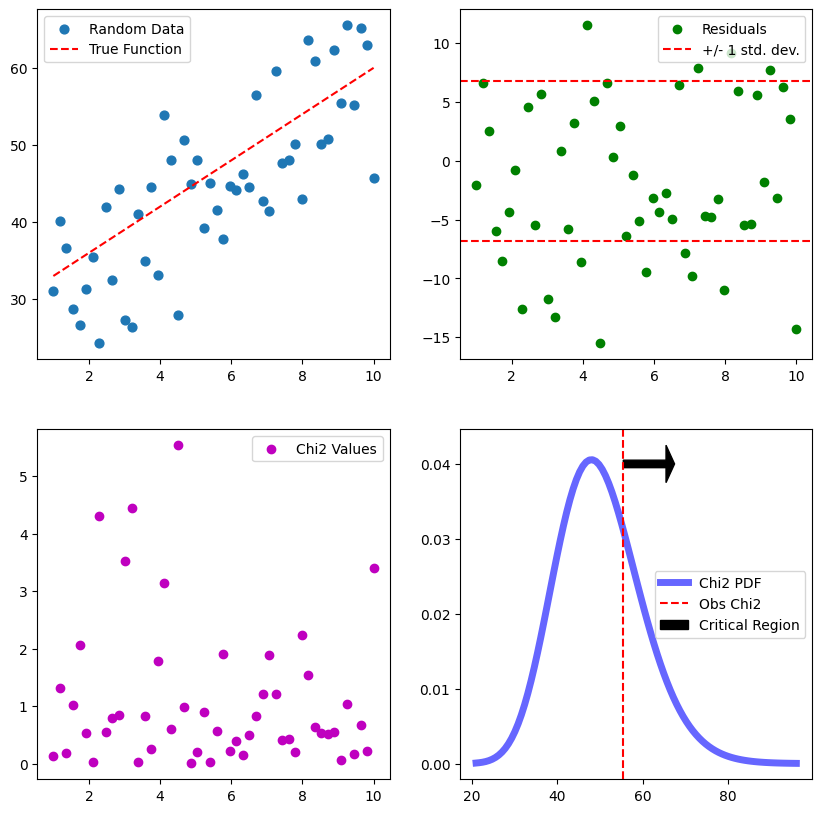


Observed Chi2:  55.46668422470934
Chi2 PDF Value:  0.031180272557158852
Chi2 CDF Value:  0.723767756712383
Observed p-value:  0.276232243287617


In [2]:
def makeData(N,xmin,xmax,slope,offset,noise):
    X = np.linspace(xmin,xmax,N)
    Y = slope*X + offset + np.random.randn(N)*noise
    return Y


# Make some data!!
# Gonna be a set of noisy data drawn from a linear function
N = 50 # number of points per class
xmin = 1 
xmax = 10
slope = 3
offset = 30
X = np.linspace(xmin,xmax,N)
xline = [xmin,xmax]
yline = [offset+xmin*slope,offset+slope*xmax]
y_true = slope*X + offset

# We will explore the role that the size of the noise plays
# Why did I choose this value to begin with?
noise = np.sqrt(np.mean(y_true))

y_data = makeData(N,xmin,xmax,slope,offset,noise)

# Calculate data!
deltaYvals = y_data - y_true  # Residuals
chi2vals = deltaYvals*deltaYvals/y_true # (d-y)^2/y

# Calculate statistics
obsChi2 = np.sum(chi2vals) # sum over array
pdfValue = stats.chi2.pdf(obsChi2,N) # What's the value of the Chi2 PDF at this observed chi2
cdfValue = stats.chi2.cdf(obsChi2,N) # Cumulative distribution function for Chi2 PDF, calculated over [-inf,Chi2]
pValue = 1-cdfValue #complement to the cdf, giving the upper tail p-value

fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

axs[0,0].scatter(X, y_data, s=40, label = "Random Data")
axs[0,0].plot(xline,yline,linestyle="--",color="r", label="True Function")
axs[0,0].legend()

axs[0,1].scatter(X,deltaYvals,label = "Residuals",c='g')
axs[0,1].axhline(y=noise,color='r',linestyle="--",label = "+/- 1 std. dev.")
axs[0,1].axhline(y=-1*noise,color='r',linestyle="--")
axs[0,1].legend()

axs[1,0].scatter(X,chi2vals,label = "Chi2 Values",color='m')
axs[1,0].legend()

chi2x = np.linspace(stats.chi2.ppf(0.0001, N), stats.chi2.ppf(0.9999, N), 100)
axs[1,1].plot(chi2x, stats.chi2.pdf(chi2x, N),
       'b-', lw=5, alpha=0.6, label='Chi2 PDF')
axs[1,1].axvline(x=obsChi2,c='r',linestyle="--",label = "Obs Chi2")
axs[1,1].arrow(obsChi2, 0.04, 10, 0, head_width=0.005, head_length=2, fc='k', ec='k',label="Critical Region")
axs[1,1].legend()
plt.show()

print("\nObserved Chi2: ",obsChi2)
print("Chi2 PDF Value: ",pdfValue)
print("Chi2 CDF Value: ",cdfValue)
print("Observed p-value: ",pValue)

In [25]:
def lhood_func_gaussian(ymodel,ydata):
    return - 0.5*np.pow((ydata - ymodel),2)/ymodel

def lhood_func_poisson(ymodel,ydata):
    return ydata*np.log(ymodel) - ymodel

def loglikelihood(pOffset,pSlope,xvals,yvals, doGaus = True):
    loglhood = 0
    y_model = pOffset + pSlope*xvals

    for i in range(0,len(xvals)):
        if doGaus:
            loglhood += lhood_func_gaussian(y_model[i],yvals[i])
        else:
            loglhood += lhood_func_poisson(y_model[i],yvals[i])
            
    return loglhood

In [30]:
steps = 200
llhood = np.zeros(shape=(steps,steps))
smin = 2
smax = 4
omin = 20.
omax = 40.
slopeVals = np.arange(smin,smax,(smax-smin)/steps)
offsetVals = np.arange(omin,omax,(omax-omin)/steps)

min = -1E7
sbest = 0
obest = 0
for x, s in enumerate(slopeVals):
    for y, o in enumerate(offsetVals):
        llhood[y,x] = loglikelihood(o,s,X,y_data,doGaus=True)
        if llhood[y,x] > min:
            min = llhood[y,x]
            sbest = s
            obest = o

-26.281121734955217 3.1499999999999755 27.70000000000011


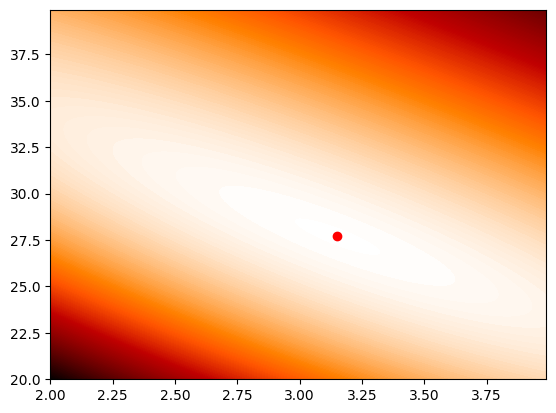

In [31]:
print(min,sbest,obest)
plt.contourf(slopeVals,offsetVals,llhood,levels = 200,cmap='gist_heat')
plt.plot(sbest,obest,'ro')
plt.show()

In [32]:
def findMin(slopeVals,offsetVals,X,y_data):
    min = -1E7
    sbest = 0
    obest = 0
    for s in slopeVals:
        for o in offsetVals:
            llhood = loglikelihood(o,s,X,y_data,doGaus=False)
            if llhood > min:
                min = llhood
                sbest = s
                obest = o
    return sbest, obest


trials = 500
pbest = np.zeros(shape=(trials,2))

for i in range(0,trials):
    pbest[i,:] = findMin(slopeVals,offsetVals,X,makeData(N,xmin,xmax,slope,offset,noise))


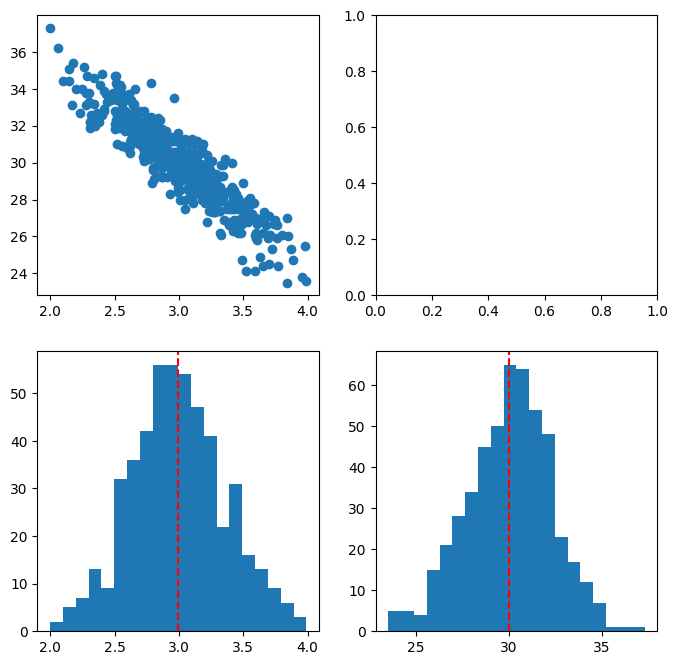

In [33]:
# Create the main figure and axes
fig, axs = plt.subplots(nrows=2,ncols=2,figsize=(8,8))

# Create the scatter plot
axs[0,0].scatter(pbest[:,0], pbest[:,1])

# Create the marginal histograms
#ax_histx = ax.inset_axes([smin, smax, 0.1, 0.2], sharex=ax)
#ax_histy = ax.inset_axes([omin, omax, 1, 1], sharey=ax)
axs[1,0].hist(pbest[:,0], bins=20)
axs[1,0].axvline(x=np.mean(pbest[:,0]),c='r',linestyle="--")

axs[1,1].hist(pbest[:,1], bins=20)
axs[1,1].axvline(x=np.mean(pbest[:,1]),c='r',linestyle="--")

plt.show()